In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv('../Data/Telco_Cusomer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop(columns=['customerID'], inplace=True)

df['Charges_Ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

top_10_cols = [
    'Contract_Two year', 'Contract_One year', 'InternetService_Fiber optic', 
    'OnlineSecurity_No internet service', 'PaymentMethod_Electronic check', 
    'InternetService_No', 'StreamingMovies_Yes', 'tenure', 
    'Charges_Ratio', 'MultipleLines_No phone service'
]

X = pd.get_dummies(df, drop_first=True)[top_10_cols]
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



--- REPORTE SVM LINEAL ---
              precision    recall  f1-score   support

           0       0.93      0.65      0.77      1036
           1       0.47      0.86      0.61       373

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.72      1409



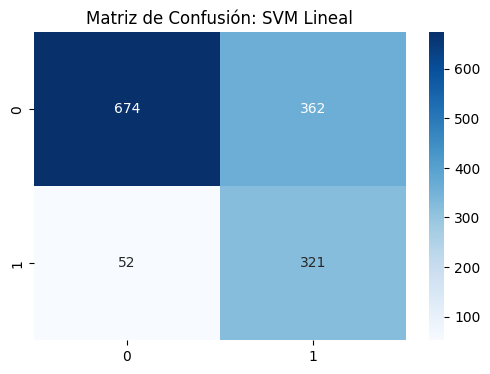

In [4]:
svm_lineal = SVC(kernel='linear', C=1.0, class_weight='balanced', probability=True, random_state=42)

svm_lineal.fit(X_train_scaled, y_train)

preds_lineal = svm_lineal.predict(X_test_scaled)

print("--- REPORTE SVM LINEAL ---")
print(classification_report(y_test, preds_lineal))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, preds_lineal), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: SVM Lineal')
plt.show()

In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

mejor_svm = grid_svm.best_estimator_
print(f"Mejores parámetros: {grid_svm.best_params_}")

preds_rbf = mejor_svm.predict(X_test_scaled)
print("\n--- REPORTE SVM (KERNEL RBF) ---")
print(classification_report(y_test, preds_rbf))

Mejores parámetros: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}

--- REPORTE SVM (KERNEL RBF) ---
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1036
           1       0.50      0.86      0.63       373

    accuracy                           0.74      1409
   macro avg       0.72      0.77      0.71      1409
weighted avg       0.82      0.74      0.75      1409



In [7]:
param_grid_pro = {
    'C': [1, 10, 100],          
    'gamma': [1, 5, 10],       
    'kernel': ['rbf']
}

grid_pro = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid_pro,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_pro.fit(X_train_scaled, y_train)

mejor_svm_pro = grid_pro.best_estimator_
print(f"Nuevos mejores parámetros: {grid_pro.best_params_}")

preds_train = mejor_svm_pro.predict(X_train_scaled)
preds_test = mejor_svm_pro.predict(X_test_scaled)

print("\n" + "="*50)
print("CONTROL DE OVERFITTING: SVM RADICAL")
print("="*50)

print("\n--- RENDIMIENTO EN ENTRENAMIENTO ---")
print(classification_report(y_train, preds_train))

print("\n--- RENDIMIENTO EN PRUEBA ---")
print(classification_report(y_test, preds_test))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Nuevos mejores parámetros: {'C': 1, 'gamma': 5, 'kernel': 'rbf'}

CONTROL DE OVERFITTING: SVM RADICAL

--- RENDIMIENTO EN ENTRENAMIENTO ---
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      4138
           1       0.52      0.84      0.64      1496

    accuracy                           0.75      5634
   macro avg       0.72      0.78      0.73      5634
weighted avg       0.82      0.75      0.77      5634


--- RENDIMIENTO EN PRUEBA ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1036
           1       0.51      0.84      0.63       373

    accuracy                           0.74      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409



In [ ]:
analisis_svm = X_test.copy()
analisis_svm['Real'] = y_test.values
analisis_svm['Pred_SVM'] = preds_test

fn_svm = analisis_svm[(analisis_svm['Real'] == 1) & (analisis_svm['Pred_SVM'] == 0)]

print(f"Antigüedad media de los que se le escapan a XGBoost: ~31 meses")
print(f"Antigüedad media de los que se le escapan a SVM: {fn_svm['tenure'].mean():.2f} meses")

print(f"Total de fugas NO detectadas por SVM: {len(fn_svm)}")

Antigüedad media de los que se le escapan a XGBoost: ~31 meses
Antigüedad media de los que se le escapan a SVM: 37.92 meses
Total de fugas NO detectadas por SVM: 60


--- REPORTE DEL ENSAMBLE (XGBoost + SVM | Umbral 0.55) ---
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1036
           1       0.58      0.74      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.79      0.80      1409



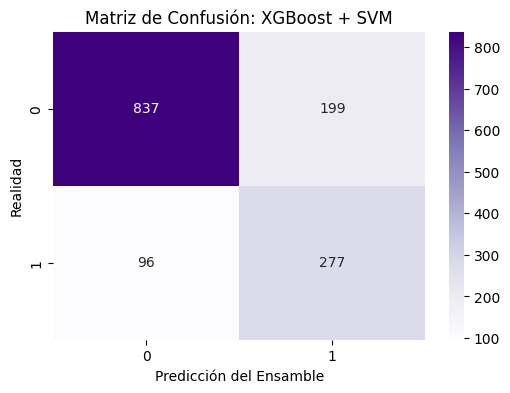

In [ ]:
import joblib

modelo_xgb_importado = joblib.load('modelo_xgboost_top10.pkl')
columnas_xgb = joblib.load('columnas_top10.pkl')

X_test_xgb = X_test[columnas_xgb]

probs_xgb = modelo_xgb_importado.predict_proba(X_test_xgb)[:, 1] 
probs_svm = mejor_svm_pro.predict_proba(X_test_scaled)[:, 1]     

probs_ensamble = (probs_xgb + probs_svm) / 2

umbral_ensamble = 0.55
predicciones_ensamble = np.where(probs_ensamble >= umbral_ensamble, 1, 0)

print(f"--- REPORTE DEL ENSAMBLE (XGBoost + SVM | Umbral {umbral_ensamble}) ---")
print(classification_report(y_test, predicciones_ensamble))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predicciones_ensamble), annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusión: XGBoost + SVM')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Ensamble')
plt.show()

In [20]:
umbrales_a_probar = [0.58]

print("=== BÚSQUEDA DEL UMBRAL DEFINITIVO (ENSAMBLE) ===\n")

for umbral in umbrales_a_probar:
    predicciones = np.where(probs_ensamble >= umbral, 1, 0)
    
    cm = confusion_matrix(y_test, predicciones)
    falsos_positivos = cm[0, 1] 
    falsos_negativos = cm[1, 0] 
    
    print(f"--- UMBRAL: {umbral} ---")
    print(f"Falsas Alarmas: {falsos_positivos} | Fugas no detectadas: {falsos_negativos}")
    print(classification_report(y_test, predicciones))
    print("-" * 60 + "\n")

=== BÚSQUEDA DEL UMBRAL DEFINITIVO (ENSAMBLE) ===

--- UMBRAL: 0.58 ---
Falsas Alarmas: 174 | Fugas no detectadas: 102
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1036
           1       0.61      0.73      0.66       373

    accuracy                           0.80      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.82      0.80      0.81      1409

------------------------------------------------------------



In [45]:
joblib.dump(mejor_svm_pro, 'modelo_svm_rbf.pkl')
joblib.dump(scaler, 'scaler_svm.pkl')

def predecir_churn_ensamble(df_nuevos_clientes, umbral=0.58):
    modelo_xgb = joblib.load('modelo_xgboost_top10.pkl')
    modelo_svm = joblib.load('modelo_svm_rbf.pkl')
    scaler_svm = joblib.load('scaler_svm.pkl')
    columnas_top10 = joblib.load('columnas_top10.pkl')
    df_ordenado = df_nuevos_clientes[columnas_top10]
    
    X_scaled = scaler_svm.transform(df_ordenado)
    
    probs_xgb = modelo_xgb.predict_proba(df_ordenado)[:, 1]
    probs_svm = modelo_svm.predict_proba(X_scaled)[:, 1]
    
    probs_finales = (probs_xgb + probs_svm) / 2
    
    veredicto = np.where(probs_finales >= umbral, '¡ALERTA: CHURN!', 'Cliente Seguro')
    
    resultados = pd.DataFrame({
        'Prob_XGBoost': [f"{p:.2%}" for p in probs_xgb],
        'Prob_SVM': [f"{p:.2%}" for p in probs_svm],
        'Prob_Ensamble': [f"{p:.2%}" for p in probs_finales],
        'Veredicto_Final': veredicto
    })
    
    return resultados


orden_oficial = [
    'Contract_Two year', 'Contract_One year', 'InternetService_Fiber optic', 
    'OnlineSecurity_No internet service', 'PaymentMethod_Electronic check', 
    'InternetService_No', 'StreamingMovies_Yes', 'tenure', 
    'Charges_Ratio', 'MultipleLines_No phone service'
]

flota_prueba = pd.DataFrame([
    [0, 0, 1, 0, 1, 0, 0, 1, 0.95, 0],   # Riesgo Extremo
    [1, 0, 0, 1, 0, 1, 0, 72, 0.01, 0],  # Riesgo Nulo
    [0, 1, 1, 0, 1, 0, 1, 10, 0.12, 0],  # Riesgo Medio
    [0, 0, 0, 0, 0, 0, 0, 24, 0.05, 1],  # Riesgo Sorpresa
    [1, 0, 1, 0, 0, 0, 1, 60, 0.02, 0]   # Riesgo Bajo
], columns=orden_oficial)

print("=== RESULTADOS DEL MOTOR DE ENSAMBLE (Umbral 0.58) ===")
reporte_final = predecir_churn_ensamble(flota_prueba, umbral=0.58)
reporte_final.insert(0, 'Perfil', ['Caminante Blanco', 'Abuelito Leal', 'Moderno Indeciso', 'Cazador Ofertas', 'Premium Atado'])
print(reporte_final)

=== RESULTADOS DEL MOTOR DE ENSAMBLE (Umbral 0.58) ===
             Perfil Prob_XGBoost Prob_SVM Prob_Ensamble  Veredicto_Final
0  Caminante Blanco       88.27%   53.99%        71.13%  ¡ALERTA: CHURN!
1     Abuelito Leal        2.55%    8.17%         5.36%   Cliente Seguro
2  Moderno Indeciso       63.17%    8.16%        35.67%   Cliente Seguro
3   Cazador Ofertas       41.03%   16.88%        28.96%   Cliente Seguro
4     Premium Atado       21.81%    8.17%        14.99%   Cliente Seguro
